In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\train_u6lujuX_CVtuZ9i (1).csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])   # categorical
    else:
        df[col] = df[col].fillna(df[col].median())    # numerical


In [7]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [8]:
df.duplicated().sum() 

np.int64(0)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [10]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


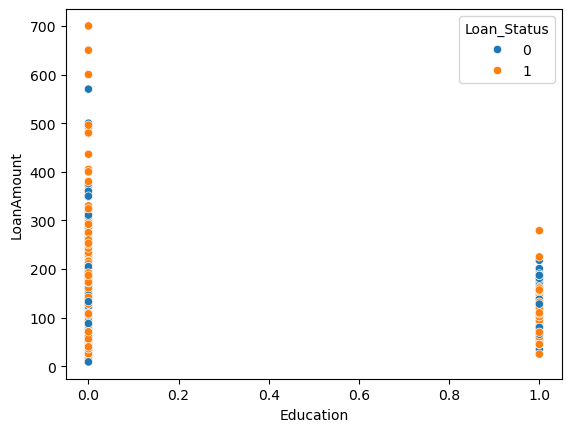

In [11]:
sns.scatterplot(x='Education', y='LoanAmount', hue='Loan_Status', data=df)
plt.show()


In [12]:
#here the datapoints are overlapping so while using SVM we need to use polynomial kernal

In [13]:
#here we need to use point Biserial correlation because here the target is catogorical(binary)and independent is numerical

In [14]:
from scipy.stats import pointbiserialr
import pandas as pd

binary_col = 'Loan_Status'   # your binary target column (0/1)

# Select only numeric columns except target
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop(binary_col)

results = {}

for col in numeric_cols:
    corr, p_value = pointbiserialr(df[binary_col], df[col])
    results[col] = {'Correlation': corr, 'p-value': p_value}

# Convert to DataFrame for better view
result_df = pd.DataFrame(results).T

print(result_df)


                   Correlation       p-value
Loan_ID               0.011773  7.709371e-01
Gender                0.017987  6.564498e-01
Married               0.091478  2.339836e-02
Dependents            0.010118  8.024165e-01
Education            -0.085884  3.336068e-02
Self_Employed        -0.003700  9.270900e-01
ApplicantIncome      -0.004710  9.072878e-01
CoapplicantIncome    -0.059187  1.429483e-01
LoanAmount           -0.033214  4.113237e-01
Loan_Amount_Term     -0.022549  5.770668e-01
Credit_History        0.540556  7.019682e-48
Property_Area         0.032112  4.270284e-01


In [15]:
# Dependent variable (target)
y = df['Loan_Status']

# Independent variables (features)
X = df[['Married', 'Education', 'Self_Employed','Credit_History']]

In [16]:
# Scale features for better KNN performance
from sklearn.preprocessing import LabelEncoder, StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Split into train-test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [18]:
#Applying SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [19]:
#Create SVM with Polynomial Kernel
svc_poly = SVC(
    kernel='poly',
    degree=3,          # degree of the polynomial (you can change)
    C=1.0,             # regularization
    gamma='scale'      # kernel coefficient
)

In [20]:
# Fit the model
svc_poly.fit(X_train, y_train)


SVC(kernel='poly')

In [21]:
# Predict
y_pred = svc_poly.predict(X_test)


In [22]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8536585365853658

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [23]:
#checking the overfitting and underfitting

In [24]:
# Training accuracy
train_pred = svc_poly.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Testing accuracy
test_pred = svc_poly.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.7983706720977597
Testing Accuracy: 0.8536585365853658


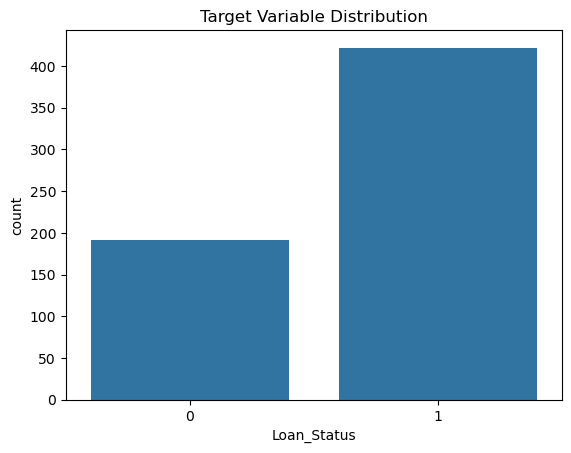

In [25]:
#checking data imbalance
sns.countplot(x='Loan_Status', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [26]:
#There is a data imbalance

In [27]:
#we can use sampling techniques such as smote

In [28]:
from imblearn.over_sampling import SMOTE


In [29]:
from sklearn.model_selection import train_test_split

X = df[['Married', 'Education', 'Self_Employed','Credit_History']]
y = df['Loan_Status']



In [30]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X,y)


In [31]:
from collections import Counter
print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_train_res))


Before SMOTE: Counter({1: 422, 0: 192})
After SMOTE: Counter({1: 422, 0: 422})


In [32]:
from sklearn.svm import SVC

svm = SVC(kernel='poly')



In [33]:
#now we can do cross validation technique 

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.model_selection import cross_val_score


In [36]:
cross_val_score(svm,X_train_res, y_train_res,cv=skf).mean()

np.float64(0.7002817695125387)

In [37]:
#applying random forest

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)



In [40]:
cross_val_score(model,X_train_res, y_train_res,cv=skf).mean()

np.float64(0.7085798816568047)

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model1 = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [43]:
cross_val_score(model1,X_train_res, y_train_res,cv=skf).mean()

np.float64(0.7097633136094675)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
# Train KNN model
knn = KNeighborsClassifier(n_neighbors=13)

In [45]:
cross_val_score(knn,X_train_res, y_train_res,cv=skf).mean()

np.float64(0.7121301775147929)

In [46]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [47]:
from xgboost import XGBClassifier

In [48]:
xg = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [49]:
cross_val_score(xg,X_train_res, y_train_res,cv=skf).mean()

np.float64(0.7121301775147929)

In [50]:
#svm with c value

In [51]:
C_values = [0.01, 0.1, 1, 10, 100]

for c in C_values:
    svmupdated= SVC(kernel='poly', C=c, gamma='scale', random_state=42)

In [52]:
cross_val_score(svmupdated,X_train_res, y_train_res,cv=skf).mean()

np.float64(0.7085798816568047)

In [53]:
#apply leave one out insted of skf

In [54]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

In [55]:
loo = LeaveOneOut()

In [56]:
cross_val_score(svmupdated,X_train_res, y_train_res,cv=loo).mean()

np.float64(0.7156398104265402)

In [1]:
#From all the algorithm we get an average of 0.70 which os an ok model